In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
E_pho = np.load('E_pho.npy')
E_nu = np.load('E_nu.npy')
E_had = np.load('E_had.npy')

In [19]:
#define constants (cgs)
G = 6.67259e-8 #gravitational constant (dyne cm2/g2)
c = 29979245800 #speed of light (cm/s)
msun = 1.989e+33 #mass of the Sun (grams)
eV2erg = 1.60218e-12

def rg(M_BH):
    '''gravitational radius (in cm) as function of SMBH mass (in units of msun)'''
    return G*msun*M_BH/(c**2)

In [ ]:
L_x_array = np.logspace(40, 45, 11) #L_X (2-10 keV) intrinsic, erg/s

#!!the template_target is the Marconi sequence for each value of L_X considered here.
#!!We release the full calculation, but check our paper for a discussion on the validity of assuming the Marconi sequence for AGN with L_X<1e42 erg/s.

template_target = np.load('sed_variable.npy') #3d: L_x_array, energy (eV), luminosity (erg/s) 

In [60]:
##choose L_x
index_lx = 6
L_X = L_x_array[index_lx]
print(L_X)

1e+43


Text(0.5, 1.0, 'Target SED (Marconi)')

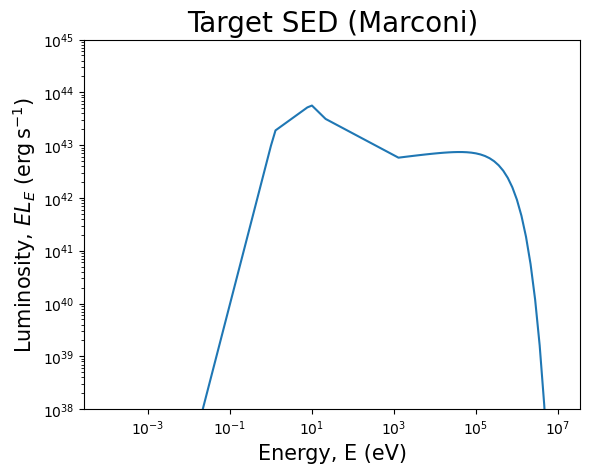

In [61]:
plt.loglog(template_target[index_lx, 0], template_target[index_lx, 1])
plt.ylim(1e38, 1e45)
plt.xlabel('Energy, E (eV)', fontsize = 15)
plt.ylabel(r'Luminosity, $EL_E$ $(\mathrm{erg}\,\mathrm{s}^{-1})$', fontsize = 15)

plt.title('Target SED (Marconi)', fontsize = 20)

In [62]:
#LOAD RADIATION (corresponding to the value of L_x chosen before)
photons = np.load(f'PHOTONS/fotoni_t_{index_lx}.npy')
neutrinos = np.load(f'NEUTRINOS/neutrini_t_{index_lx}.npy')

sigmagrid=np.logspace(-2,0,22) 
etagrid=np.logspace(-2,0,20) 
rgrid = np.logspace(np.log10(1e12), np.log10(1e16), 18) #cm
"dimensions: sigma_tur, eta, R, Energy. The F_p parameter is a rescaling. Here F_p = 1"

'dimensions: sigma_tur, eta, R, Energy. The F_p parameter is a rescaling. Here F_p = 1'

In [67]:
#example
index = [15, 8, 5]
sigma = sigmagrid[index[0]]
eta = etagrid[index[1]]
radius = rgrid[index[2]]
F_p = 0.1

volume = 4/3 * np.pi * radius**3
t_escape = radius/c

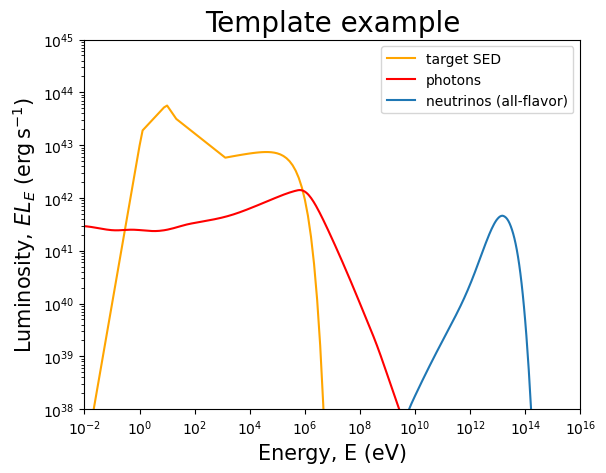

In [68]:
#plot luminosities for best-fit solution
plt.loglog(template_target[index_lx, 0], template_target[index_lx, 1], color = 'orange', label = 'target SED')
plt.loglog(E_pho, F_p * eV2erg*E_pho*photons[index[0], index[1], index[2], :] * volume / t_escape, color = 'red', label = 'photons')
plt.loglog(E_nu, F_p * eV2erg*E_nu*neutrinos[index[0], index[1], index[2], :] * volume / t_escape, label = 'neutrinos (all-flavor)')

plt.ylim(1e38, 1e45)
plt.xlim(1e-2, 1e16)
plt.xlabel('Energy, E (eV)', fontsize = 15)
plt.ylabel(r'Luminosity, $EL_E$ $(\mathrm{erg}\,\mathrm{s}^{-1})$', fontsize = 15)

plt.title('Template example', fontsize = 20)
plt.legend()